In [1]:
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import seaborn as sns
import anndata as ad
import scanpy as sc
import os
from napari_spatialdata import Interactive
from spatialdata import SpatialData
from spatialdata.models import PointsModel, TableModel
from spatialdata import polygon_query
import dask.dataframe as dd
import natsort
import geopandas as gpd
from sklearn.preprocessing import LabelEncoder

os.chdir("E:/202411_HPV原位测序毕设数据/数据分析/5_小论文Fig5/")
os.getcwd()

E:\Anaconda\envs\spatialdata-io\lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


'E:\\202411_HPV原位测序毕设数据\\数据分析\\5_小论文Fig5'

# 交互式区域选择

In [214]:
sample_dir = 'E:/202411_HPV原位测序毕设数据/1_Epi8问题一/20241211/2418014'
sample_id = sample_dir.strip('/').split('/')[-1]
if not os.path.exists(sample_id):
    os.makedirs(sample_id)
    
### 结果读取
mx = pd.read_csv(sample_dir + '/outs/Matrix.csv', index_col = 0)
centroids = pd.read_csv(sample_dir + '/outs/CellCentroid.csv', index_col = 2)
centroids = centroids.loc[mx.index, :]

### 创建anndata
adata = ad.AnnData(
    X = mx,
    dtype = np.float32,
    obs = centroids,
    obsm = {'spatial': centroids[["column","row"]].copy().to_numpy()},
    uns = {'spatialdata_attrs': {'instance_key': 'cell_id', 'region': 'kelab', 'region_key': 'library_id'}}) # 否则polygon_query报错
adata.obs['library_id'] = 'kelab'
adata.obs['cell_id'] = adata.obs.index

### 创建SpatialData对象
my_points = {"Cells": PointsModel.parse(adata.obs, coordinates = {'x': 'column', 'y': 'row'})}
my_tables = {"table": TableModel.parse(adata)}
sdata = SpatialData(points = my_points, tables = my_tables)

### 打开Napari
interactive = Interactive(sdata)
interactive.run()

E:\Anaconda\envs\spatialdata-io\lib\site-packages\anndata\_core\anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
E:\Anaconda\envs\spatialdata-io\lib\functools.py:926: UserWarning: The index of the dataframe is not monotonic increasing. It is recommended to sort the data to adjust the order of the index before calling .parse() (or call `parse(sort=True)`) to avoid possible problems due to unknown divisions.
  return method.__get__(obj, cls)(*args, **kwargs)
E:\Anaconda\envs\spatialdata-io\lib\site-packages\spatialdata\_core\spatialdata.py:185: UserWarning: The table is annotating 'kelab', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
2025-06-12 17:09:04.632 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-06-12 17:09:52.294 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2025-06-12 17:09:52.297 | DEBUG    | napari_spati

INFO: Layer(s) inherited info from Cells
INFO: Layer saved


In [215]:
### 获取polygon
polygon = sdata['Shapes'].geometry.iloc[0]

### 获取polygon下的anndata
roi = polygon_query(sdata, polygon = polygon, target_coordinate_system = 'global')
adata = adata[roi['Cells']['cell_id'].compute().to_list(),:]

adata

View of AnnData object with n_obs × n_vars = 5323 × 13
    obs: 'row', 'column', 'library_id', 'cell_id'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [329]:
mx

,CRYAB,GAS5,HPV_E6,HPV_E7,HSPA1B,KRT13,KRT5,NME2,RPL13,RPLP1,SNHG29,SNHG5,SNHG8
cell name,,,,,,,,,,,,,
cell_2712,2,0,0,0,0,2,2,0,0,1,0,0,0
cell_2713,1,0,0,0,0,1,1,0,0,0,0,0,0
cell_2722,0,0,0,0,0,0,1,0,0,1,0,0,0
cell_2723,0,0,0,1,0,1,0,0,0,3,0,0,0
cell_2724,3,0,0,1,1,1,6,0,0,3,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
cell_16871,0,0,0,0,0,0,1,0,0,0,0,0,0
cell_16872,2,0,0,0,0,0,2,0,0,0,0,0,0
cell_16873,0,0,0,0,0,0,1,0,0,1,0,0,0


# 可视化 (epi8)

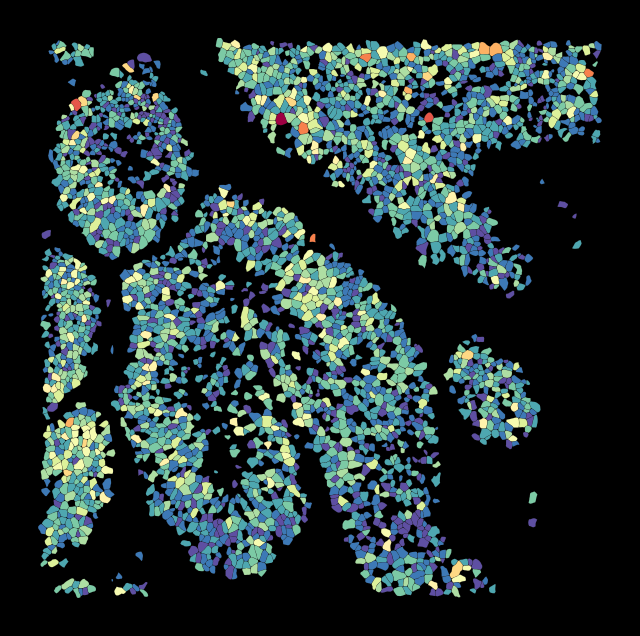

In [216]:
# 过滤细胞
mx = mx.loc[adata.obs_names,]
centroids = centroids.loc[adata.obs_names,]

# 上皮细胞注释
epi = mx[(mx['KRT5'] > 0) | (mx['KRT13'] > 0)]
centroids = centroids.loc[mx.index, :]
centroids.loc[:, 'class'] = 'other'
centroids.loc[epi.index, 'class'] = 'epithelium'
centroids['name'] = centroids.index

# 定义epi8
epi8 = epi.loc[:, ['CRYAB', 'GAS5', 'HSPA1B', 'NME2', 'RPL13', 'RPLP1', 'SNHG29', 'SNHG5', 'SNHG8']]
epi8_sum = epi8.sum(axis=1) 
centroids.loc[:, 'epi8_sum'] = epi8_sum 

# 进行标准化：将 epi8_sum 标准化到 0-1 范围
epi8_min = epi8_sum.min()
epi8_max = epi8_sum.max()
centroids['epi8_sum_normalized'] = (epi8_sum - epi8_min) / (epi8_max - epi8_min)

# 砖块图准备
geojson_file = sample_dir + "/outs/cells/Cells.geojson"
gdf = gpd.read_file(geojson_file)
gdf = gdf.merge(centroids[['row', 'column', 'class', 'name', 'epi8_sum_normalized']], on=['name'], how='left')
gdf.dropna(inplace=True)

# 过滤符合条件的细胞
gdf = gdf[gdf['name'].isin(adata.obs_names.to_list())]

# 砖块图可视化
plt.style.use('dark_background')
figure_size = (8, 8)
fig, axes = plt.subplots(1, 1, figsize=figure_size)

# 绘制砖块图，颜色映射使用 'epi8_sum'（连续数值）
gdf.plot(ax=axes, column='epi8_sum_normalized', cmap='Spectral_r', edgecolor='#666666', linewidth=0.05, aspect=1)

# 设置y轴反转，去除坐标轴
axes.invert_yaxis()
axes.set_aspect('auto')
axes.set_axis_off()

# 保存结果图像
plt.savefig(sample_id + '/Plot1.pdf', dpi=300, transparent=False, bbox_inches='tight')

# 可视化 (单基因)

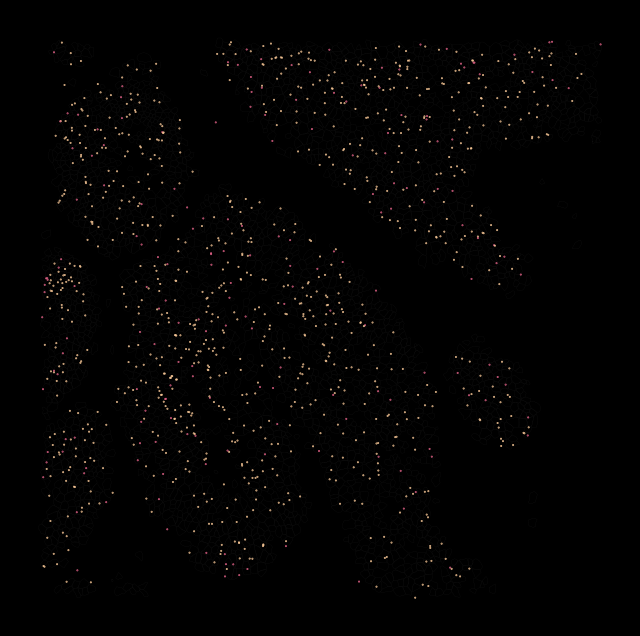

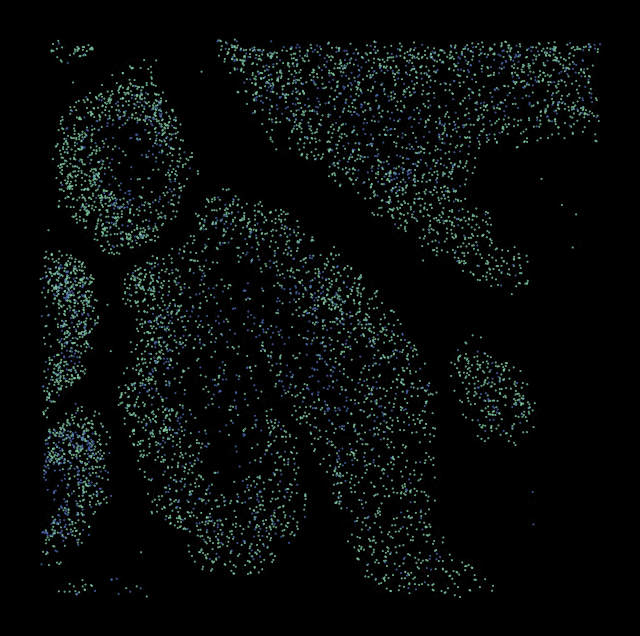

In [217]:
###
gene = pd.read_csv(sample_dir + '/outs/CellGene.csv')
gene = gene[gene['cell'].isin(adata.obs_names.to_list())]
gene_color_map = {
    'KRT5': '#82CCA4', 
    'KRT13': '#4C66AC', 
    'HPV_E6': '#e7648a',
    'HPV_E7': '#fecc9a'
}
gene['color'] = gene['gene'].map(gene_color_map)

### HPV_E6 HPV_E7 可视化
hpv = gene[gene['gene'].isin(['HPV_E6', 'HPV_E7'])]
### 砖块图可视化
plt.style.use('dark_background')
figure_size = (8,8)
fig, axes = plt.subplots(1,1,figsize = figure_size)
gdf.plot(ax = axes, color = 'black', edgecolor='#a6a6a6', linewidth=0.02, aspect=1)
### 画基因散点图（x 和 y 列为坐标，gene列为颜色）
scatter = axes.scatter(hpv['x'], hpv['y'], c=hpv['color'], s = 0.2, alpha=1)
axes.invert_yaxis()
axes.set_aspect('auto')
axes.set_axis_off()
plt.savefig(sample_id + '/Plot2.pdf', dpi=300, transparent=False, bbox_inches='tight')

### KRT5 KRT13 可视化
krt = gene[gene['gene'].isin(['KRT5', 'KRT13'])]
### 砖块图可视化
plt.style.use('dark_background')
figure_size = (8,8)
fig, axes = plt.subplots(1,1,figsize = figure_size)
gdf.plot(ax = axes, color = 'black', edgecolor='#a6a6a6', linewidth=0.02, aspect=1)
### 画基因散点图（x 和 y 列为坐标，gene列为颜色）
scatter = axes.scatter(krt['x'], krt['y'], c=krt['color'], s = 0.2, alpha=1)
axes.invert_yaxis()
axes.set_aspect('auto')
axes.set_axis_off()
plt.savefig(sample_id + '/Plot3.pdf', dpi=300, transparent=False, bbox_inches='tight')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4688\1151359897.py:32: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(distances_to_krt5, shade=True, color="#82CCA4", label="Distances to KRT5", bw_adjust=1)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4688\1151359897.py:35: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(distances_to_krt13, shade=True, color="#4C66AC", label="Distances to KRT13", bw_adjust=1)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4688\1151359897.py:38: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(distances_to_hpv6, shade=True, color="#e7648a", label="Distances to HPV_E6", bw_adjust=

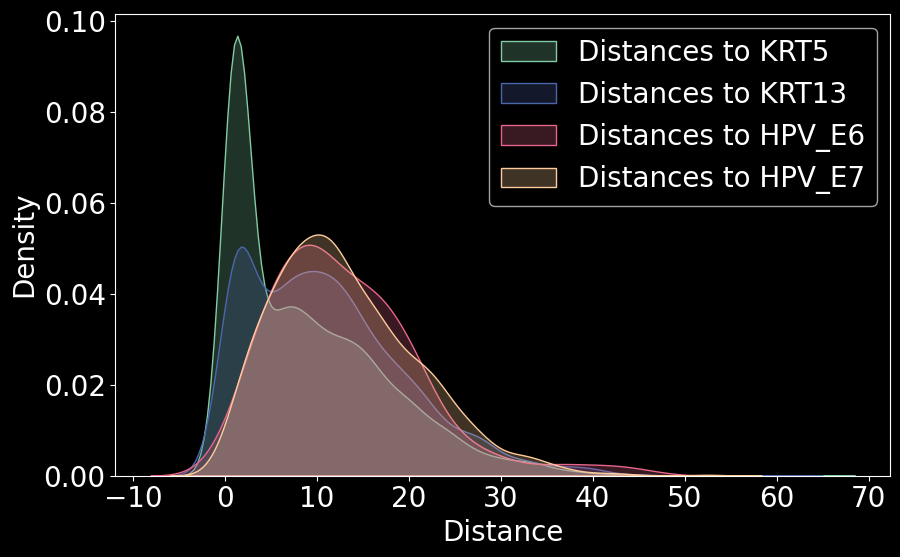

In [218]:
from scipy.spatial import KDTree
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 获取epi8基因数据的二维坐标
genes_coords = gene[gene['gene'].isin(['CRYAB', 'GAS5', 'HSPA1B', 'NME2', 'RPL13', 'RPLP1', 'SNHG29', 'SNHG5', 'SNHG8'])][['y', 'x']].values

# 创建KD树
kdtree = KDTree(genes_coords)

# 查询每个基因到最近KRT5的距离
krt5_coords = gene[gene['gene'] == 'KRT5'][['y', 'x']].values
distances_to_krt5, _ = kdtree.query(krt5_coords, k=1) 

# 查询每个基因到最近KRT13的距离
krt13_coords = gene[gene['gene'] == 'KRT13'][['y', 'x']].values
distances_to_krt13, _ = kdtree.query(krt13_coords, k=1) 

# 查询每个基因到最近HPV_E6的距离
hpv6_coords = gene[gene['gene'] == 'HPV_E6'][['y', 'x']].values
distances_to_hpv6, _ = kdtree.query(hpv6_coords, k=1)

# 查询每个基因到最近HPV_E6的距离
hpv7_coords = gene[gene['gene'] == 'HPV_E7'][['y', 'x']].values
distances_to_hpv7, _ = kdtree.query(hpv7_coords, k=1)

# 使用 Seaborn 绘制两条 KDE 图并区分颜色
plt.figure(figsize=(10, 6))

# KDE for KRT5 distances with a label and color
sns.kdeplot(distances_to_krt5, shade=True, color="#82CCA4", label="Distances to KRT5", bw_adjust=1)

# KDE for KRT13 distances with a label and color
sns.kdeplot(distances_to_krt13, shade=True, color="#4C66AC", label="Distances to KRT13", bw_adjust=1)

# KDE for HPV_E6 distances with a label and color
sns.kdeplot(distances_to_hpv6, shade=True, color="#e7648a", label="Distances to HPV_E6", bw_adjust=1)

# KDE for HPV_E7 distances with a label and color
sns.kdeplot(distances_to_hpv7, shade=True, color="#fecc9a", label="Distances to HPV_E7", bw_adjust=1)

# 设置图形标题和标签
plt.xlabel('Distance',fontsize=20)
plt.ylabel('Density',fontsize=20)

# 添加图例
plt.legend()

# 添加图例并调大字体
plt.legend(fontsize=20)

# 设置x轴范围
# plt.xlim(0, max(np.max(distances_to_krt5[:, 1]), np.max(distances_to_hpv[:, 1])))
# plt.xlim(-5, 50)

# 调整坐标轴标签字体大小
plt.tick_params(axis='both', labelsize=20)

plt.savefig(sample_id + '/Plot4.pdf', dpi=300, transparent=False, bbox_inches='tight')

In [219]:
### 保存anndata
adata.write_h5ad(sample_id + '/' + sample_id + '.h5ad')

### 保存距离表格
df = pd.DataFrame({
    'Distance': np.concatenate([distances_to_krt5, distances_to_krt13, distances_to_hpv6, distances_to_hpv7]),
    'Gene': ['KRT5'] * len(distances_to_krt5) + 
            ['KRT13'] * len(distances_to_krt13) + 
            ['HPV_E6'] * len(distances_to_hpv6) + 
            ['HPV_E7'] * len(distances_to_hpv7),
    'Sample': [sample_id] * (len(distances_to_krt5) + len(distances_to_krt13) + len(distances_to_hpv6) + len(distances_to_hpv7)),
    'Group': ['ISCC'] * (len(distances_to_krt5) + len(distances_to_krt13) + len(distances_to_hpv6) + len(distances_to_hpv7))
})
df.to_csv(sample_id + '/Table_' + sample_id + '.csv')

E:\Anaconda\envs\spatialdata-io\lib\site-packages\anndata\_core\anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


In [ ]:
### 调整每个样本的KDE图

sample_dir = 'E:/202411_HPV原位测序毕设数据/1_Epi8问题一/20241211/2418014/////////////////'
sample_id = sample_dir.strip('/').split('/')[-1]
if not os.path.exists(sample_id):
    os.makedirs(sample_id)
    
### 结果读取
adata = sc.read_h5ad(sample_id + '/' + sample_id + '.h5ad')
gene = pd.read_csv(sample_dir + '/outs/CellGene.csv')
gene = gene[gene['cell'].isin(adata.obs_names.to_list())]

# 获取epi8基因数据的二维坐标
genes_coords = gene[gene['gene'].isin(['CRYAB', 'GAS5', 'HSPA1B', 'NME2', 'RPL13', 'RPLP1', 'SNHG29', 'SNHG5', 'SNHG8'])][['y', 'x']].values

# 创建KD树
kdtree = KDTree(genes_coords)

# 查询每个基因到最近KRT5的距离
krt5_coords = gene[gene['gene'] == 'KRT5'][['y', 'x']].values
distances_to_krt5, _ = kdtree.query(krt5_coords, k=1) 

# 查询每个基因到最近KRT13的距离
krt13_coords = gene[gene['gene'] == 'KRT13'][['y', 'x']].values
distances_to_krt13, _ = kdtree.query(krt13_coords, k=1) 

# 查询每个基因到最近HPV_E6的距离
hpv6_coords = gene[gene['gene'] == 'HPV_E6'][['y', 'x']].values
distances_to_hpv6, _ = kdtree.query(hpv6_coords, k=1)

# 查询每个基因到最近HPV_E6的距离
hpv7_coords = gene[gene['gene'] == 'HPV_E7'][['y', 'x']].values
distances_to_hpv7, _ = kdtree.query(hpv7_coords, k=1)

# 使用 Seaborn 绘制两条 KDE 图并区分颜色
plt.figure(figsize=(10, 6))
plt.style.use('dark_background')

# KDE for KRT5 distances with a label and color
sns.kdeplot(distances_to_krt5, shade=True, color="#82CCA4", label="Distances to KRT5", bw_adjust=1, alpha = 0.8)

# KDE for KRT13 distances with a label and color
sns.kdeplot(distances_to_krt13, shade=True, color="#4C66AC", label="Distances to KRT13", bw_adjust=1, alpha = 0.8)

# KDE for HPV_E6 distances with a label and color
sns.kdeplot(distances_to_hpv6, shade=True, color="#e7648a", label="Distances to HPV_E6", bw_adjust=1, alpha = 0.8)

# KDE for HPV_E7 distances with a label and color
sns.kdeplot(distances_to_hpv7, shade=True, color="#fecc9a", label="Distances to HPV_E7", bw_adjust=1, alpha = 0.8)

# 设置图形标题和标签
plt.xlabel('Distance',fontsize=20)
plt.ylabel('Density',fontsize=20)

# 添加图例
plt.legend()

# 添加图例并调大字体
plt.legend(fontsize=20)

# 设置x轴范围
# plt.xlim(0, max(np.max(distances_to_krt5[:, 1]), np.max(distances_to_hpv[:, 1])))
plt.xlim(-5, 40)

# 调整坐标轴标签字体大小
plt.tick_params(axis='both', labelsize=20)

plt.savefig(sample_id + '/Plot4.pdf', dpi=300, transparent=False, bbox_inches='tight')

# 整合分析

In [222]:
def read_csv_files_in_folder(folder_path):
    
    # 创建一个空的 DataFrame 用于存储合并的结果
    result_df = pd.DataFrame()

    # 递归遍历文件夹
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            # 如果是CSV文件
            if file.endswith('.csv'):
                file_path = os.path.join(root, file)
                try:
                    # 读取 CSV 文件并将其添加到 result_df 中
                    temp_df = pd.read_csv(file_path, index_col = 0)
                    result_df = pd.concat([result_df, temp_df], ignore_index=True)
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")
    
    return result_df

# 使用方法
folder_path = 'E:/202411_HPV原位测序毕设数据/数据分析/5_小论文Fig5/'
result = read_csv_files_in_folder(folder_path)
result

,Distance,Gene,Sample,Group
0,2.061553,KRT5,2400585,ISCC
1,7.071068,KRT5,2400585,ISCC
2,5.220153,KRT5,2400585,ISCC
3,1.500000,KRT5,2400585,ISCC
4,4.743416,KRT5,2400585,ISCC
...,...,...,...,...
542308,58.380219,HPV_E7,2418792,LSIL
542309,18.439089,HPV_E7,2418792,LSIL
542310,21.476732,HPV_E7,2418792,LSIL
542311,8.514693,HPV_E7,2418792,LSIL


E:\Anaconda\envs\spatialdata-io\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
E:\Anaconda\envs\spatialdata-io\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
E:\Anaconda\envs\spatialdata-io\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
E:\Anaconda\envs\spatialdata-io\lib\site-packages\se

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Normal vs. LSIL: Kruskal-Wallis independent samples (pairwise between groups), P_val:0.000e+00 Stat=3.240e+03
HSIL vs. ISCC: Kruskal-Wallis independent samples (pairwise between groups), P_val:5.137e-26 Stat=1.113e+02


E:\Anaconda\envs\spatialdata-io\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
E:\Anaconda\envs\spatialdata-io\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
E:\Anaconda\envs\spatialdata-io\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
E:\Anaconda\envs\spatialdata-io\lib\site-packages\se

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Normal vs. LSIL: Kruskal-Wallis independent samples (pairwise between groups), P_val:0.000e+00 Stat=3.240e+03
HSIL vs. ISCC: Kruskal-Wallis independent samples (pairwise between groups), P_val:5.137e-26 Stat=1.113e+02


E:\Anaconda\envs\spatialdata-io\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
E:\Anaconda\envs\spatialdata-io\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
E:\Anaconda\envs\spatialdata-io\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
E:\Anaconda\envs\spatialdata-io\lib\site-packages\se

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Normal vs. LSIL: Kruskal-Wallis independent samples (pairwise between groups), P_val:0.000e+00 Stat=3.240e+03
HSIL vs. ISCC: Kruskal-Wallis independent samples (pairwise between groups), P_val:5.137e-26 Stat=1.113e+02


E:\Anaconda\envs\spatialdata-io\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
E:\Anaconda\envs\spatialdata-io\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
E:\Anaconda\envs\spatialdata-io\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
E:\Anaconda\envs\spatialdata-io\lib\site-packages\se

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Normal vs. LSIL: Kruskal-Wallis independent samples (pairwise between groups), P_val:0.000e+00 Stat=3.240e+03
HSIL vs. ISCC: Kruskal-Wallis independent samples (pairwise between groups), P_val:5.137e-26 Stat=1.113e+02


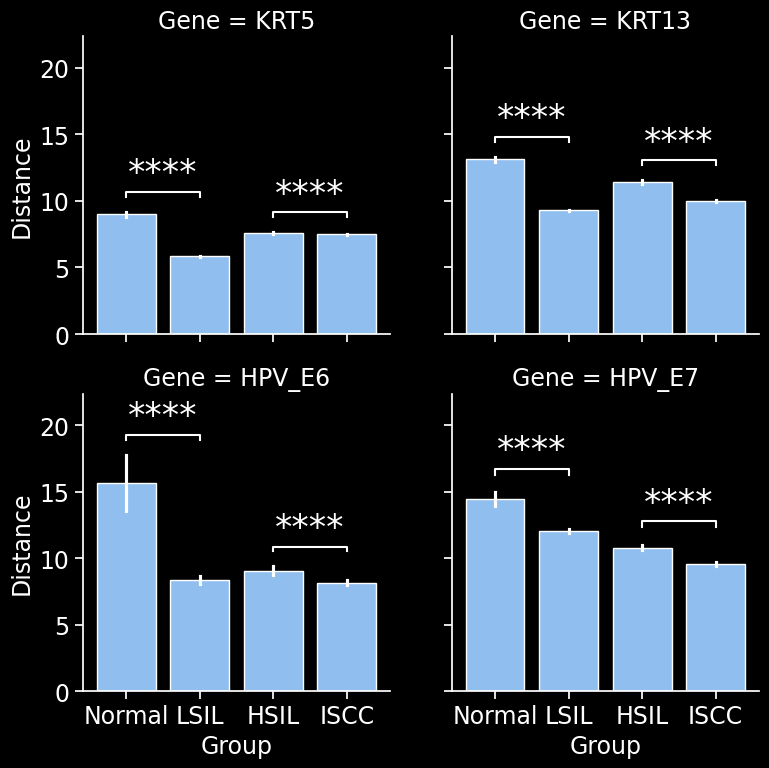

In [322]:
# 组间差异总柱状图

from statannotations.Annotator import Annotator

# 设置 Seaborn 的字体大小（扩大一倍）
sns.set_context("notebook", rc={"font.size": 17, "axes.titlesize": 17, "axes.labelsize": 17, "xtick.labelsize": 17, "ytick.labelsize": 17})

# 创建 catplot，设置为2x2布局
g = sns.catplot(
    data=result, kind="bar",
    x="Group", y="Distance", col="Gene", order=['Normal', 'LSIL', 'HSIL', 'ISCC'],color='#80bfff',
    height=4, aspect=1, col_wrap=2  # 每个子图高度为 4，宽高比为 1
)

# 获取每个子图的误差条对象并设置为白色
for ax in g.axes.flat:
    # 设置误差条颜色为白色
    for bar in ax.patches:
        bar.set_edgecolor("white")

# 调整图形大小（总体大小）
g.fig.set_size_inches(8, 8)  # 这里设置整个图像的大小为 8x8

# 循环每个子图，并在每个子图上应用 Annotator
for ax in g.axes.flat:
    annotator = Annotator(ax, 
                         [("Normal", "LSIL"), ("HSIL","ISCC")], 
                         data=result, x='Group', y='Distance', order=['Normal', 'LSIL', 'HSIL', 'ISCC'], fontsize=30, color = 'white')
    
    # 配置 Kruskal 检验和显著性标注样式
    annotator.configure(test="Kruskal", text_format='star', loc='inside', fontsize=25)

    # 应用并添加标注，设置组间差异横线为白色
    annotator.apply_and_annotate()
    
    # 获取并调整横线的颜色
    for line in ax.lines:  # 获取图中的横线对象
        line.set_color('white')  # 设置横线的颜色为白色
        
# 调整子图之间的间距，以避免重叠
plt.subplots_adjust(hspace=0.2, wspace=0.2)

# 保存图表
plt.savefig('Bar_Distance.pdf', dpi=300, transparent=False, bbox_inches='tight')

# 各Group的KDE图

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4688\3740776481.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(lsil_distances_to_krt5['Distance'], shade=True, color="#82CCA4", label="Distances to KRT5", bw_adjust=1, alpha = 0.8)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4688\3740776481.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(lsil_distances_to_krt13['Distance'], shade=True, color="#4C66AC", label="Distances to KRT13", bw_adjust=1, alpha = 0.8)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4688\3740776481.py:18: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(lsil_distances_to_hpv6['Dis

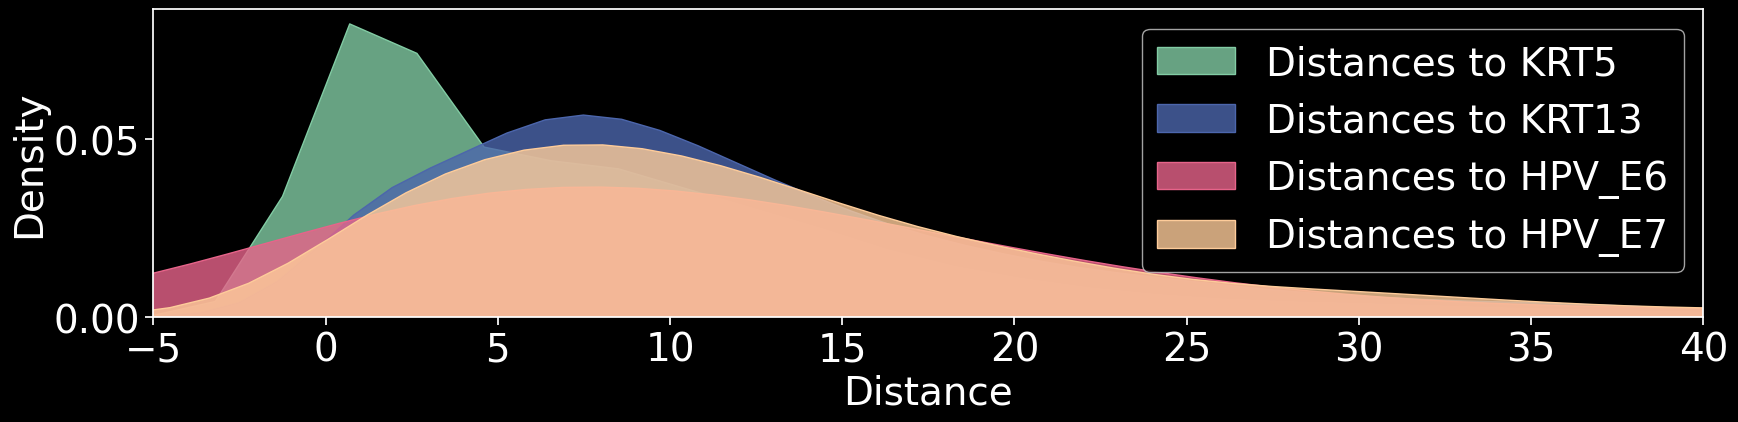

In [318]:
# Normal
lsil = result[result['Group'] == 'Normal']
lsil_distances_to_krt5 = lsil[lsil['Gene'] == 'KRT5']
lsil_distances_to_krt13 = lsil[lsil['Gene'] == 'KRT13']
lsil_distances_to_hpv6 = lsil[lsil['Gene'] == 'HPV_E6']
lsil_distances_to_hpv7 = lsil[lsil['Gene'] == 'HPV_E7']

# 使用 Seaborn 绘制两条 KDE 图并区分颜色
plt.figure(figsize=(20, 4))

# KDE for KRT5 distances with a label and color
sns.kdeplot(lsil_distances_to_krt5['Distance'], shade=True, color="#82CCA4", label="Distances to KRT5", bw_adjust=1, alpha = 0.8)

# KDE for KRT13 distances with a label and color
sns.kdeplot(lsil_distances_to_krt13['Distance'], shade=True, color="#4C66AC", label="Distances to KRT13", bw_adjust=1, alpha = 0.8)

# KDE for HPV_E6 distances with a label and color
sns.kdeplot(lsil_distances_to_hpv6['Distance'], shade=True, color="#e7648a", label="Distances to HPV_E6", bw_adjust=1, alpha = 0.8)

# KDE for HPV_E7 distances with a label and color
sns.kdeplot(lsil_distances_to_hpv7['Distance'], shade=True, color="#fecc9a", label="Distances to HPV_E7", bw_adjust=1, alpha = 0.8)

# 设置图形标题和标签
plt.xlabel('Distance',fontsize=28)
plt.ylabel('Density',fontsize=28)

# 添加图例
plt.legend()

# 添加图例并调大字体
plt.legend(fontsize=28)

# 设置x轴范围
# plt.xlim(0, max(np.max(distances_to_krt5[:, 1]), np.max(distances_to_hpv[:, 1])))
plt.xlim(-5, 40)

# 调整坐标轴标签字体大小
plt.tick_params(axis='both', labelsize=28)

plt.savefig('KDE_Normal.pdf', dpi=300, transparent=False, bbox_inches='tight')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4688\1888375054.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(lsil_distances_to_krt5['Distance'], shade=True, color="#82CCA4", label="Distances to KRT5", bw_adjust=1, alpha = 0.8)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4688\1888375054.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(lsil_distances_to_krt13['Distance'], shade=True, color="#4C66AC", label="Distances to KRT13", bw_adjust=1, alpha = 0.8)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4688\1888375054.py:18: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(lsil_distances_to_hpv6['Dis

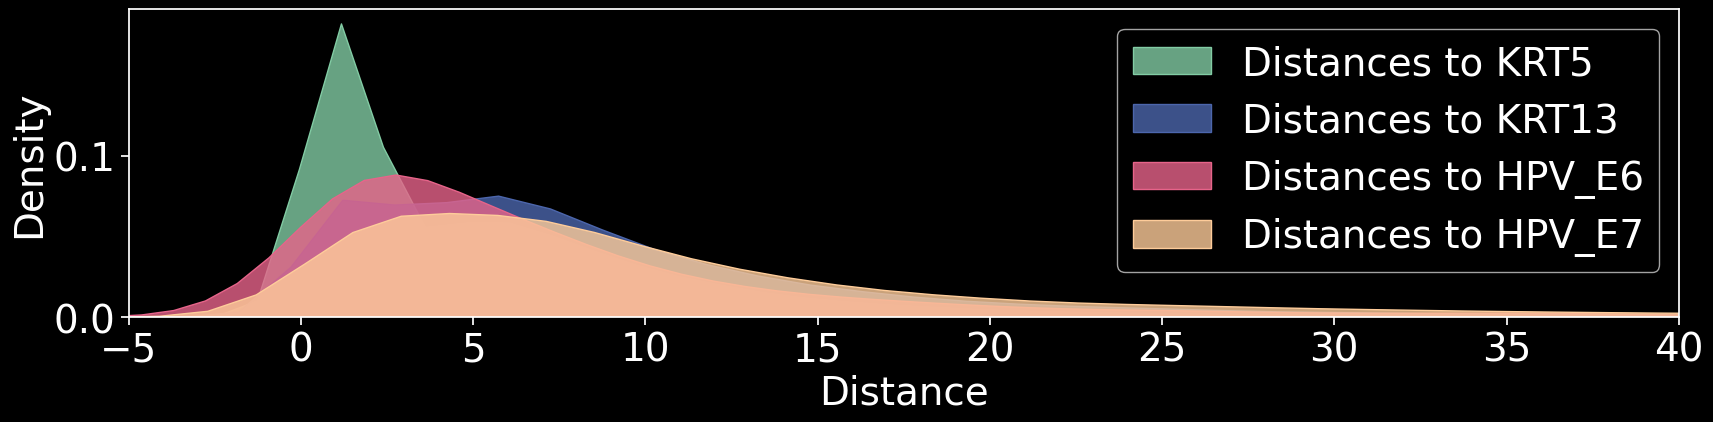

In [319]:
# LSIL 
lsil = result[result['Group'] == 'LSIL']
lsil_distances_to_krt5 = lsil[lsil['Gene'] == 'KRT5']
lsil_distances_to_krt13 = lsil[lsil['Gene'] == 'KRT13']
lsil_distances_to_hpv6 = lsil[lsil['Gene'] == 'HPV_E6']
lsil_distances_to_hpv7 = lsil[lsil['Gene'] == 'HPV_E7']

# 使用 Seaborn 绘制两条 KDE 图并区分颜色
plt.figure(figsize=(20, 4))

# KDE for KRT5 distances with a label and color
sns.kdeplot(lsil_distances_to_krt5['Distance'], shade=True, color="#82CCA4", label="Distances to KRT5", bw_adjust=1, alpha = 0.8)

# KDE for KRT13 distances with a label and color
sns.kdeplot(lsil_distances_to_krt13['Distance'], shade=True, color="#4C66AC", label="Distances to KRT13", bw_adjust=1, alpha = 0.8)

# KDE for HPV_E6 distances with a label and color
sns.kdeplot(lsil_distances_to_hpv6['Distance'], shade=True, color="#e7648a", label="Distances to HPV_E6", bw_adjust=1, alpha = 0.8)

# KDE for HPV_E7 distances with a label and color
sns.kdeplot(lsil_distances_to_hpv7['Distance'], shade=True, color="#fecc9a", label="Distances to HPV_E7", bw_adjust=1, alpha = 0.8)

# 设置图形标题和标签
plt.xlabel('Distance',fontsize=28)
plt.ylabel('Density',fontsize=28)

# 添加图例
plt.legend()

# 添加图例并调大字体
plt.legend(fontsize=28)

# 设置x轴范围
# plt.xlim(0, max(np.max(distances_to_krt5[:, 1]), np.max(distances_to_hpv[:, 1])))
plt.xlim(-5, 40)

# 调整坐标轴标签字体大小
plt.tick_params(axis='both', labelsize=28)

plt.savefig('KDE_LSIL.pdf', dpi=300, transparent=False, bbox_inches='tight')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4688\118826902.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(lsil_distances_to_krt5['Distance'], shade=True, color="#82CCA4", label="Distances to KRT5", bw_adjust=1, alpha = 0.8)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4688\118826902.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(lsil_distances_to_krt13['Distance'], shade=True, color="#4C66AC", label="Distances to KRT13", bw_adjust=1, alpha = 0.8)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4688\118826902.py:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(lsil_distances_to_hpv6['Distan

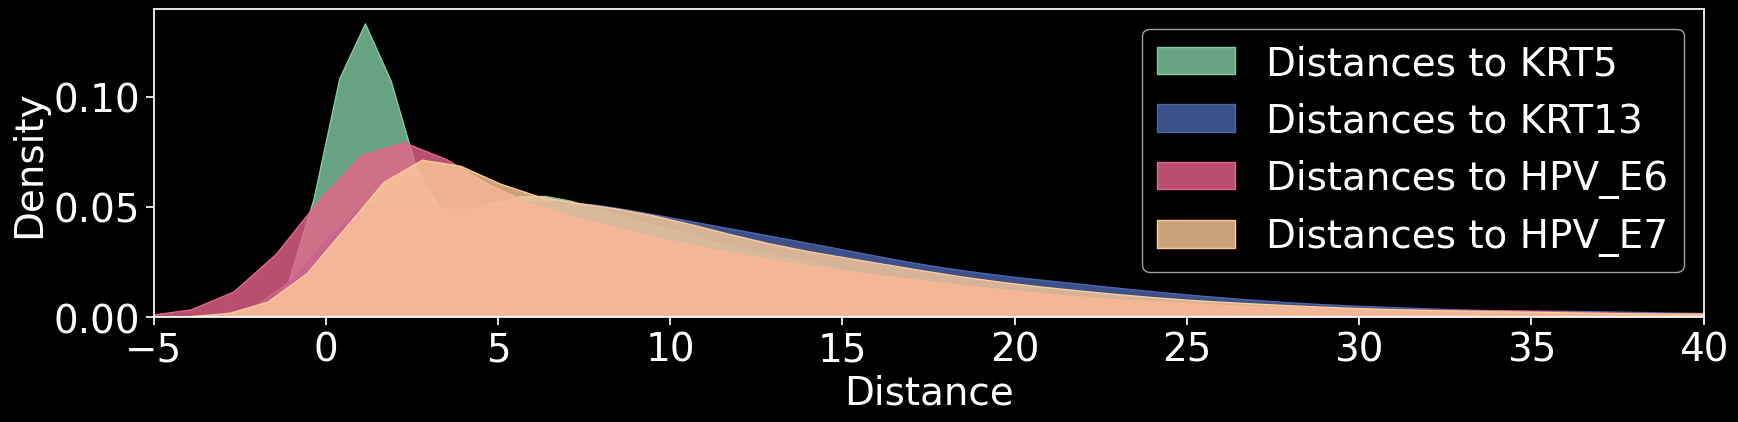

In [320]:
# HSIL
lsil = result[result['Group'] == 'HSIL']
lsil_distances_to_krt5 = lsil[lsil['Gene'] == 'KRT5']
lsil_distances_to_krt13 = lsil[lsil['Gene'] == 'KRT13']
lsil_distances_to_hpv6 = lsil[lsil['Gene'] == 'HPV_E6']
lsil_distances_to_hpv7 = lsil[lsil['Gene'] == 'HPV_E7']

# 使用 Seaborn 绘制两条 KDE 图并区分颜色
plt.figure(figsize=(20, 4))

# KDE for KRT5 distances with a label and color
sns.kdeplot(lsil_distances_to_krt5['Distance'], shade=True, color="#82CCA4", label="Distances to KRT5", bw_adjust=1, alpha = 0.8)

# KDE for KRT13 distances with a label and color
sns.kdeplot(lsil_distances_to_krt13['Distance'], shade=True, color="#4C66AC", label="Distances to KRT13", bw_adjust=1, alpha = 0.8)

# KDE for HPV_E6 distances with a label and color
sns.kdeplot(lsil_distances_to_hpv6['Distance'], shade=True, color="#e7648a", label="Distances to HPV_E6", bw_adjust=1, alpha = 0.8)

# KDE for HPV_E7 distances with a label and color
sns.kdeplot(lsil_distances_to_hpv7['Distance'], shade=True, color="#fecc9a", label="Distances to HPV_E7", bw_adjust=1, alpha = 0.8)

# 设置图形标题和标签
plt.xlabel('Distance',fontsize=28)
plt.ylabel('Density',fontsize=28)

# 添加图例
plt.legend()

# 添加图例并调大字体
plt.legend(fontsize=28)

# 设置x轴范围
# plt.xlim(0, max(np.max(distances_to_krt5[:, 1]), np.max(distances_to_hpv[:, 1])))
plt.xlim(-5, 40)

# 调整坐标轴标签字体大小
plt.tick_params(axis='both', labelsize=28)

plt.savefig('KDE_HSIL.pdf', dpi=300, transparent=False, bbox_inches='tight')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4688\429419850.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(lsil_distances_to_krt5['Distance'], shade=True, color="#82CCA4", label="Distances to KRT5", bw_adjust=1, alpha = 0.8)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4688\429419850.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(lsil_distances_to_krt13['Distance'], shade=True, color="#4C66AC", label="Distances to KRT13", bw_adjust=1, alpha = 0.8)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4688\429419850.py:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(lsil_distances_to_hpv6['Distan

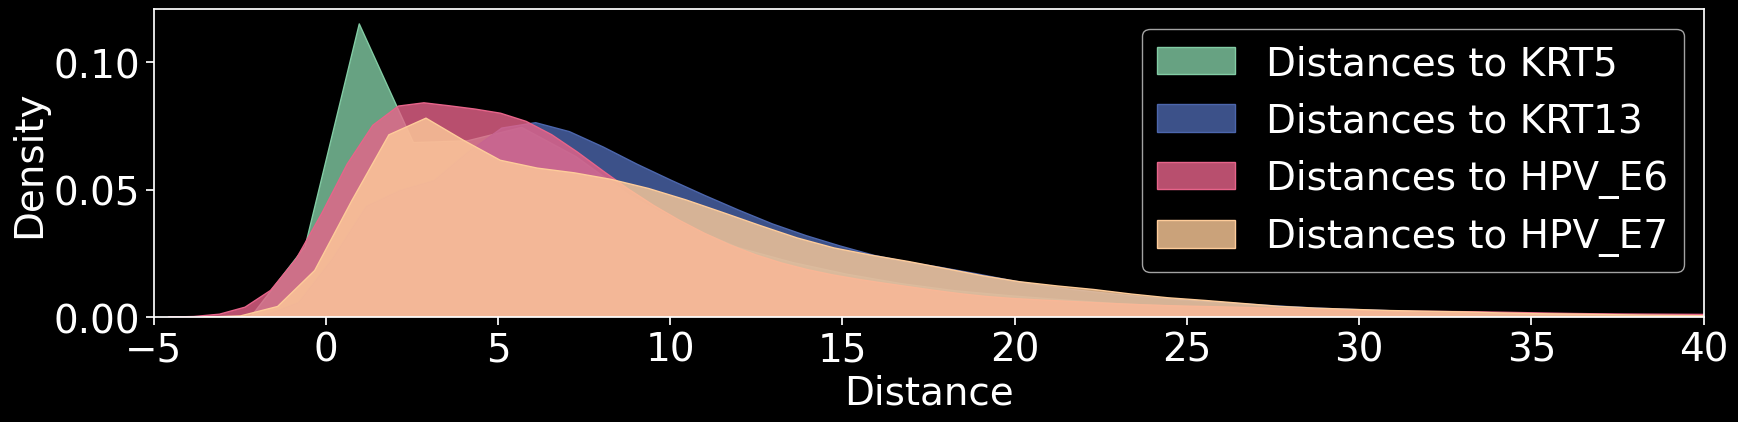

In [321]:
# ISCC
lsil = result[result['Group'] == 'ISCC']
lsil_distances_to_krt5 = lsil[lsil['Gene'] == 'KRT5']
lsil_distances_to_krt13 = lsil[lsil['Gene'] == 'KRT13']
lsil_distances_to_hpv6 = lsil[lsil['Gene'] == 'HPV_E6']
lsil_distances_to_hpv7 = lsil[lsil['Gene'] == 'HPV_E7']

# 使用 Seaborn 绘制两条 KDE 图并区分颜色
plt.figure(figsize=(20, 4))

# KDE for KRT5 distances with a label and color
sns.kdeplot(lsil_distances_to_krt5['Distance'], shade=True, color="#82CCA4", label="Distances to KRT5", bw_adjust=1, alpha = 0.8)

# KDE for KRT13 distances with a label and color
sns.kdeplot(lsil_distances_to_krt13['Distance'], shade=True, color="#4C66AC", label="Distances to KRT13", bw_adjust=1, alpha = 0.8)

# KDE for HPV_E6 distances with a label and color
sns.kdeplot(lsil_distances_to_hpv6['Distance'], shade=True, color="#e7648a", label="Distances to HPV_E6", bw_adjust=1, alpha = 0.8)

# KDE for HPV_E7 distances with a label and color
sns.kdeplot(lsil_distances_to_hpv7['Distance'], shade=True, color="#fecc9a", label="Distances to HPV_E7", bw_adjust=1, alpha = 0.8)

# 设置图形标题和标签
plt.xlabel('Distance',fontsize=28)
plt.ylabel('Density',fontsize=28)

# 添加图例
plt.legend()

# 添加图例并调大字体
plt.legend(fontsize=28)

# 设置x轴范围
# plt.xlim(0, max(np.max(distances_to_krt5[:, 1]), np.max(distances_to_hpv[:, 1])))
plt.xlim(-5, 40)

# 调整坐标轴标签字体大小
plt.tick_params(axis='both', labelsize=28)

plt.savefig('KDE_ISCC.pdf', dpi=300, transparent=False, bbox_inches='tight')

In [326]:
result.groupby(['Gene', 'Group'])['Distance'].mean().reset_index()

,Gene,Group,Distance
0,HPV_E6,HSIL,9.061673
1,HPV_E6,ISCC,8.165055
2,HPV_E6,LSIL,8.379259
3,HPV_E6,Normal,15.624581
4,HPV_E7,HSIL,10.781111
5,HPV_E7,ISCC,9.558415
6,HPV_E7,LSIL,12.012489
7,HPV_E7,Normal,14.451464
8,KRT13,HSIL,11.439270
9,KRT13,ISCC,9.969691
